In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    dev = "cuda:0"
elif torch.backends.mps.is_available():
    dev = "mps"
else:
    dev = "cpu"
device = torch.device(dev)
device

device(type='mps')

In [3]:
class MobileFaceEmbedding(nn.Module):
    def __init__(self, embedding_size=512, pretrained=True):
        super().__init__()
        base = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None)
        base.classifier = nn.Identity()
        self.backbone = base
        self.embedding = nn.Sequential(
            nn.Linear(576, 1024),
            nn.Hardswish(),
            nn.Linear(1024, embedding_size)
        )
        self.bn = nn.BatchNorm1d(embedding_size)

    def forward(self, x):
        x = self.backbone(x)
        x = self.embedding(x)
        x = self.bn(x)
        x = nn.functional.normalize(x, dim=1)
        return x

In [4]:
model = MobileFaceEmbedding(embedding_size=512).to(device)

state_dict = torch.load("mobileface_arcface_finetuned.pth", map_location=device)
model.load_state_dict(state_dict)

model.eval()

MobileFaceEmbedding(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          

In [5]:
preprocess = MobileNet_V3_Small_Weights.IMAGENET1K_V1.transforms()

train_ds = ImageFolder(root="faces/train", transform=preprocess)
val_ds = ImageFolder(root="faces/dev", transform=preprocess)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

In [6]:
def build_gallery(model, dataloader):
    """Compute one embedding per identity (mean of all their images)."""
    model.eval()
    embeddings_per_label = {}
    counts = {}

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Building gallery"):
            imgs = imgs.to(device)
            embs = F.normalize(model(imgs), dim=1)
            for emb, lbl in zip(embs.cpu(), labels):
                lbl = int(lbl)
                if lbl not in embeddings_per_label:
                    embeddings_per_label[lbl] = emb.clone()
                    counts[lbl] = 1
                else:
                    embeddings_per_label[lbl] += emb
                    counts[lbl] += 1

    # Average embeddings per class
    for lbl in embeddings_per_label:
        embeddings_per_label[lbl] /= counts[lbl]

    labels = list(embeddings_per_label.keys())
    gallery_embs = torch.stack([embeddings_per_label[l] for l in labels])
    gallery_labels = torch.tensor(labels)

    return gallery_embs, gallery_labels

gallery_embs, gallery_labels = build_gallery(model, train_dl)
print(f"Built gallery for {len(gallery_labels)} identities.")

Building gallery: 100%|██████████| 4376/4376 [02:38<00:00, 27.53it/s]

Built gallery for 7001 identities.


In [7]:
gallery_embs = F.normalize(gallery_embs, dim=1).to(device)
gallery_labels = gallery_labels.to(device)

In [8]:
def identify(model, query_imgs, gallery_embs, gallery_labels):
    """Find most similar identity in the gallery for each query."""
    model.eval()
    with torch.no_grad():
        query_embs = F.normalize(model(query_imgs), dim=1)
        sims = torch.mm(query_embs, gallery_embs.T)  # cosine similarity
        best_idx = torch.argmax(sims, dim=1)
        pred_labels = gallery_labels[best_idx]
        best_scores = sims[torch.arange(len(sims)), best_idx]
    return pred_labels.cpu(), best_scores.cpu()

In [9]:
correct = 0
total = 0

with torch.no_grad():
    for Xv, yv in tqdm(val_dl, desc="Evaluating"):
        Xv, yv = Xv.to(device), yv.to(device)
        pred_labels, _ = identify(model, Xv, gallery_embs, gallery_labels)
        correct += (pred_labels == yv.cpu()).sum().item()
        total += yv.size(0)

top1_acc = correct / total
print(f"Top-1 identification accuracy: {top1_acc*100:.2f}%")

Evaluating: 100%|██████████| 1094/1094 [00:43<00:00, 25.23it/s]

Top-1 identification accuracy: 84.00%


In [10]:
model.eval()
embs, labels = [], []

with torch.no_grad():
    for imgs, lbls in val_dl:
        imgs = imgs.to(device)
        out = model(imgs)
        out = F.normalize(out, dim=1)
        embs.append(out.cpu())
        labels.append(lbls)

emb_sample = torch.cat(embs)     # [N, D]
lab_sample = torch.cat(labels)   # [N]

emb_norm = F.normalize(emb_sample, dim=1)
sim_matrix = torch.mm(emb_norm, emb_norm.T)
idx_i, idx_j = torch.triu_indices(sim_matrix.size(0), sim_matrix.size(1), offset=1)
sims = sim_matrix[idx_i, idx_j]
same_mask = lab_sample[idx_i] == lab_sample[idx_j]
same_sims = sims[same_mask]
diff_sims = sims[~same_mask]

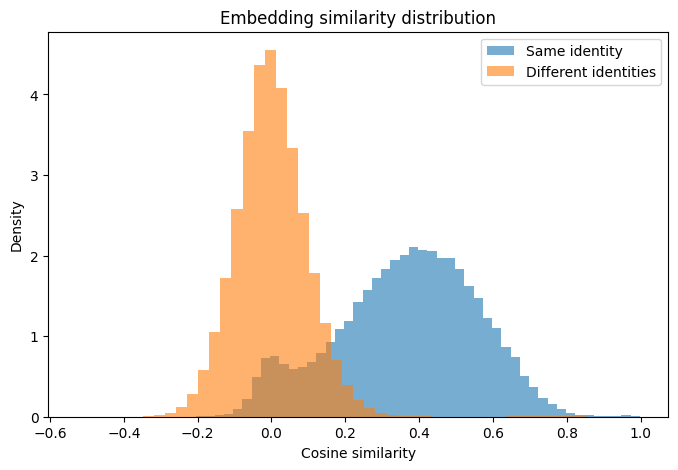

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(same_sims, bins=50, alpha=0.6, label="Same identity", density=True)
plt.hist(diff_sims, bins=50, alpha=0.6, label="Different identities", density=True)
plt.xlabel("Cosine similarity")
plt.ylabel("Density")
plt.legend()
plt.title("Embedding similarity distribution")
plt.savefig("embedding_similarity_distribution.png")